**Support Vector Machines**

Venkata Naga Sai Gajula
Module 3 Assignment on SVM

_This notebook contains all the sample code and solutions to the exercises in chapter 5._

<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/ageron/handson-ml3/blob/main/05_support_vector_machines.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
  </td>
  <td>
    <a target="_blank" href="https://kaggle.com/kernels/welcome?src=https://github.com/ageron/handson-ml3/blob/main/05_support_vector_machines.ipynb"><img src="https://kaggle.com/static/images/open-in-kaggle.svg" /></a>
  </td>
</table>

# Setup

This project requires Python 3.7 or above:

In [4]:
import sys

assert sys.version_info >= (3, 7)

It also requires Scikit-Learn ≥ 1.0.1:

In [5]:
from packaging import version
import sklearn

assert version.parse(sklearn.__version__) >= version.parse("1.0.1")

As we did in previous chapters, let's define the default font sizes to make the figures prettier:

In [6]:
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

And let's create the `images/svm` folder (if it doesn't already exist), and define the `save_fig()` function which is used through this notebook to save the figures in high-res for the book:

In [7]:
from pathlib import Path

IMAGES_PATH = Path() / "images" / "svm"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

# 10.

_Exercise: Train an SVM classifier on the Wine dataset, which you can load using `sklearn.datasets.load_wine()`. This dataset contains the chemical analysis of 178 wine samples produced by 3 different cultivators: the goal is to train a classification model capable of predicting the cultivator based on the wine's chemical analysis. Since SVM classifiers are binary classifiers, you will need to use one-versus-all to classify all 3 classes. What accuracy can you reach?_

First, let's fetch the dataset, look at its description, then split it into a training set and a test set:

In [8]:
from sklearn.datasets import load_wine

wine = load_wine(as_frame=True)

In [9]:
print(wine.DESCR)

.. _wine_dataset:

Wine recognition dataset
------------------------

**Data Set Characteristics:**

:Number of Instances: 178
:Number of Attributes: 13 numeric, predictive attributes and the class
:Attribute Information:
    - Alcohol
    - Malic acid
    - Ash
    - Alcalinity of ash
    - Magnesium
    - Total phenols
    - Flavanoids
    - Nonflavanoid phenols
    - Proanthocyanins
    - Color intensity
    - Hue
    - OD280/OD315 of diluted wines
    - Proline
    - class:
        - class_0
        - class_1
        - class_2

:Summary Statistics:

============================= ==== ===== ======= =====
                                Min   Max   Mean     SD
============================= ==== ===== ======= =====
Alcohol:                      11.0  14.8    13.0   0.8
Malic Acid:                   0.74  5.80    2.34  1.12
Ash:                          1.36  3.23    2.36  0.27
Alcalinity of Ash:            10.6  30.0    19.5   3.3
Magnesium:                    70.0 162.0    99.7  14.3

explain what class 0,1,2 represent, and what we are trying to do with this Support Vector Machine (SVM)

In the Wine dataset, 'class 0', 'class 1', and 'class 2' represent the three distinct cultivators (or producers) of the wine samples. The objective is to train a Support Vector Machine (SVM) to classify each wine sample into its correct cultivator category based on its chemical analysis. Since SVMs are primarily binary classifiers, a 'one-versus-all' strategy is employed to handle this three-class classification problem.

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    wine.data, wine.target, random_state=42)

In [11]:
X_train.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
100,12.08,2.08,1.70,17.5,97.0,2.23,2.17,0.26,1.40,3.30,1.27,2.96,710.0
122,12.42,4.43,2.73,26.5,102.0,2.20,2.13,0.43,1.71,2.08,0.92,3.12,365.0
154,12.58,1.29,2.10,20.0,103.0,1.48,0.58,0.53,1.40,7.60,0.58,1.55,640.0
51,13.83,1.65,2.60,17.2,94.0,2.45,2.99,0.22,2.29,5.60,1.24,3.37,1265.0


In [12]:
y_train.head()

,target
2,0
100,1
122,1
154,2
51,0


Let's start simple, with a linear SVM classifier. It will automatically use the One-vs-All (also called One-vs-the-Rest, OvR) strategy, so there's nothing special we need to do to handle multiple classes. Easy, right?

In [14]:
from sklearn.svm import LinearSVC

lin_clf = LinearSVC(dual=True, random_state=42)
lin_clf.fit(X_train, y_train)

/usr/local/lib/python3.13/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


LinearSVC(dual=True, random_state=42)

Oh no! It failed to converge. Can you guess why? Do you think we must just increase the number of training iterations? Let's see:

why LinearSVC failed to converge

The `LinearSVC` model failed to converge because the features were not scaled. Support Vector Machines, including `LinearSVC`, are sensitive to the feature scales. When features have very different ranges, the optimization algorithm can struggle to find a good solution within a reasonable number of iterations, leading to convergence warnings.

In [15]:
lin_clf = LinearSVC(max_iter=1_000_000, dual=True, random_state=42)
lin_clf.fit(X_train, y_train)

/usr/local/lib/python3.13/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


LinearSVC(dual=True, max_iter=1000000, random_state=42)

Even with one million iterations, it still did not converge. There must be another problem.

Let's still evaluate this model with `cross_val_score`, it will serve as a baseline:

In [16]:
from sklearn.model_selection import cross_val_score

cross_val_score(lin_clf, X_train, y_train).mean()

/usr/local/lib/python3.13/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


np.float64(0.90997150997151)

Well 91% accuracy on this dataset is not great. So did you guess what the problem is?

That's right, we forgot to scale the features! Always remember to scale the features when using SVMs:

What is 'scaling the features'

Feature scaling is a data preprocessing technique that standardizes the range of independent variables or features of the dataset. Essentially, it transforms the data so that all features have a similar scale, preventing features with larger values from dominating the learning process.  

**Why is it important for SVMs?**

Support Vector Machines, like many other machine learning algorithms that rely on distance calculations (e.g., K-Nearest Neighbors, neural networks), are highly sensitive to the scale of the input features. If features have very different ranges:

1.  **Dominance of Larger Values:** Features with larger numerical ranges can disproportionately influence the distance calculations and, consequently, the cost function. This means the algorithm might be biased towards these features, even if they are not the most informative.
2.  **Slower Convergence:** The optimization algorithm used to find the optimal hyperplane (or decision boundary) in SVMs might take much longer to converge, or even fail to converge, if the features are on different scales. This is because the gradients used in optimization will be much larger for features with larger ranges, leading to erratic updates to the model parameters.

**How is it typically done?**

Common scaling methods include:

*   **Standardization (Z-score normalization):** Transforms data to have a mean of 0 and a standard deviation of 1. This is what `StandardScaler` in scikit-learn does.
*   **Normalization (Min-Max scaling):** Scales data to a fixed range, usually 0 to 1.

In the previous example, the `LinearSVC` failed to converge because the features of the wine dataset (e.g., 'alcohol' vs. 'proline') had vastly different scales. Applying `StandardScaler` before training the SVM resolved this convergence issue and significantly improved the model's performance.

In [18]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.pipeline import make_pipeline

lin_clf = make_pipeline(StandardScaler(),
                        LinearSVC(dual=True, random_state=42))
lin_clf.fit(X_train, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('linearsvc', LinearSVC(dual=True, random_state=42))])

Now it converges without any problem. Let's measure its performance:

In [19]:
from sklearn.model_selection import cross_val_score

cross_val_score(lin_clf, X_train, y_train).mean()

np.float64(0.9774928774928775)

Nice! We get 97.7% accuracy, that's much better.

Let's see if a kernelized SVM will do better. We will use a default `SVC` for now:

What is a 'Kernelized SVM'

A 'Kernelized SVM' refers to a Support Vector Machine that uses the "kernel trick" to handle non-linearly separable data.  

**The Kernel Trick Explained:**

*   **Linear SVMs:** A standard (linear) SVM tries to find a straight line (or hyperplane in higher dimensions) that best separates data points into different classes.
*   **Non-linear Data:** However, many real-world datasets are not linearly separable; you can't draw a single straight line to perfectly separate the classes.
*   **High-Dimensional Mapping:** The kernel trick allows SVMs to implicitly map the input data into a much higher-dimensional space where it *is* linearly separable. Instead of actually performing this computationally expensive mapping, the kernel function calculates the dot product of the data points in this higher-dimensional space directly from the original lower-dimensional space. This allows the SVM to find a non-linear decision boundary in the original feature space, without explicitly transforming the data.

**Benefits of Kernelized SVMs:**

*   **Handles Complex Relationships:** They can model complex non-linear relationships between features, leading to more flexible and powerful classifiers.
*   **Computational Efficiency:** The kernel trick avoids the explicit computation of coordinates in a high-dimensional feature space, making it computationally feasible.

**Common Kernel Functions:**

*   **Polynomial Kernel:** Creates polynomial decision boundaries.
*   **Radial Basis Function (RBF) / Gaussian Kernel:** A popular choice that can map samples into an infinite-dimensional space, often producing excellent results for a wide range of datasets. This is the default kernel used in `sklearn.svm.SVC`.
*   **Sigmoid Kernel:** Based on the hyperbolic tangent function.

In the notebook, after trying a `LinearSVC` which finds linear boundaries, the `SVC` with a default RBF kernel is introduced to see if it can achieve better performance by finding more complex, non-linear boundaries in the data.

In [21]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

svm_clf = make_pipeline(StandardScaler(), SVC(random_state=42))
cross_val_score(svm_clf, X_train, y_train).mean()

np.float64(0.9698005698005698)

That's not better, but perhaps we need to do a bit of hyperparameter tuning:

what is hyperparameter tuning and what hyperparameters are being tuned in this exercise.

Hyperparameter tuning is the process of finding the optimal set of hyperparameters for a machine learning model to achieve the best possible performance on a given task. Unlike model parameters (which are learned from the data during training), hyperparameters are external configuration settings that need to be set before the training process begins.

**Why is it important?**

Different hyperparameters can drastically change a model's behavior, leading to varying levels of performance. By systematically searching for the best hyperparameter values, we can:

*   **Improve Model Performance:** Optimize the model's accuracy, precision, recall, or other relevant metrics.
*   **Prevent Overfitting/Underfitting:** Find a balance where the model generalizes well to new, unseen data.
*   **Adapt to Specific Datasets:** The optimal hyperparameters for one dataset might not be the best for another.

**In this exercise, for the `SVC` (Support Vector Classifier) model, the following hyperparameters are being tuned:**

1.  **`C` (Regularization Parameter):** This hyperparameter controls the trade-off between achieving a low training error and a low testing error (i.e., generalizing well to unseen data). A small `C` makes the decision boundary smoother (more tolerant to misclassifications), while a large `C` aims to classify all training examples correctly, which can lead to a more complex decision boundary and potential overfitting.
2.  **`gamma` (Kernel Coefficient):** This parameter defines how far the influence of a single training example reaches, with low values meaning 'far' and high values meaning 'close'. It affects the shape of the decision boundary and how tightly the model tries to fit the training data. For kernels like the Radial Basis Function (RBF), a smaller `gamma` means a larger influence radius, resulting in a smoother decision boundary, while a larger `gamma` leads to a more complex, wiggly decision boundary that can capture fine details but risks overfitting.

The `RandomizedSearchCV` is used here to efficiently explore a wide range of values for `C` and `gamma` (defined by `loguniform` and `uniform` distributions) to find the combination that yields the highest cross-validation score.

In [22]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform, uniform

param_distrib = {
    "svc__gamma": loguniform(0.001, 0.1),
    "svc__C": uniform(1, 10)
}
rnd_search_cv = RandomizedSearchCV(svm_clf, param_distrib, n_iter=100, cv=5,
                                   random_state=42)
rnd_search_cv.fit(X_train, y_train)
rnd_search_cv.best_estimator_

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('svc',
                 SVC(C=np.float64(9.925589984899778),
                     gamma=np.float64(0.011986281799901188),
                     random_state=42))])

In [23]:
rnd_search_cv.best_score_

np.float64(0.9925925925925926)

Ah, this looks excellent! Let's select this model. Now we can test it on the test set:

In [24]:
rnd_search_cv.score(X_test, y_test)

0.9777777777777777

"rnd_search_cv.score(X_test, y_test)"; explain what the results mean

The line `rnd_search_cv.score(X_test, y_test)` evaluates the performance of the best Support Vector Classifier (SVC) model found during the hyperparameter tuning process (`rnd_search_cv`) on the previously unseen test dataset (`X_test`, `y_test`).

Here's what the result `0.9777777777777777` means:

*   **`rnd_search_cv`**: This object holds the `SVC` model that performed best during the `RandomizedSearchCV`'s cross-validation on the training data, after being tuned for `C` and `gamma` hyperparameters.
*   **`X_test` and `y_test`**: These are the features and target labels of the test set, respectively. This data was explicitly held back from the training and hyperparameter tuning phases to provide an unbiased evaluation of the final model's performance.
*   **`.score()`**: For classification models in scikit-learn, the `score()` method by default calculates the **accuracy** of the model. Accuracy is the proportion of correctly classified instances out of the total instances.

Therefore, the result `0.9777777777777777` indicates that the best-tuned SVC model achieved approximately **97.78% accuracy** on the test set. This means it correctly predicted the cultivator class for about 97.78% of the wine samples in the test set. As the subsequent text cell notes, this score is slightly lower than the cross-validation score, which is a common observation and suggests a slight overfitting to the cross-validation sets.

This tuned kernelized SVM performs better than the `LinearSVC` model, but we get a lower score on the test set than we measured using cross-validation. This is quite common: since we did so much hyperparameter tuning, we ended up slightly overfitting the cross-validation test sets. It's tempting to tweak the hyperparameters a bit more until we get a better result on the test set, but this would probably not help, as we would just start overfitting the test set. Anyway, this score is not bad at all, so let's stop here.

generate a visualization of prediction vs actual class for the first 20 data entries in the test set

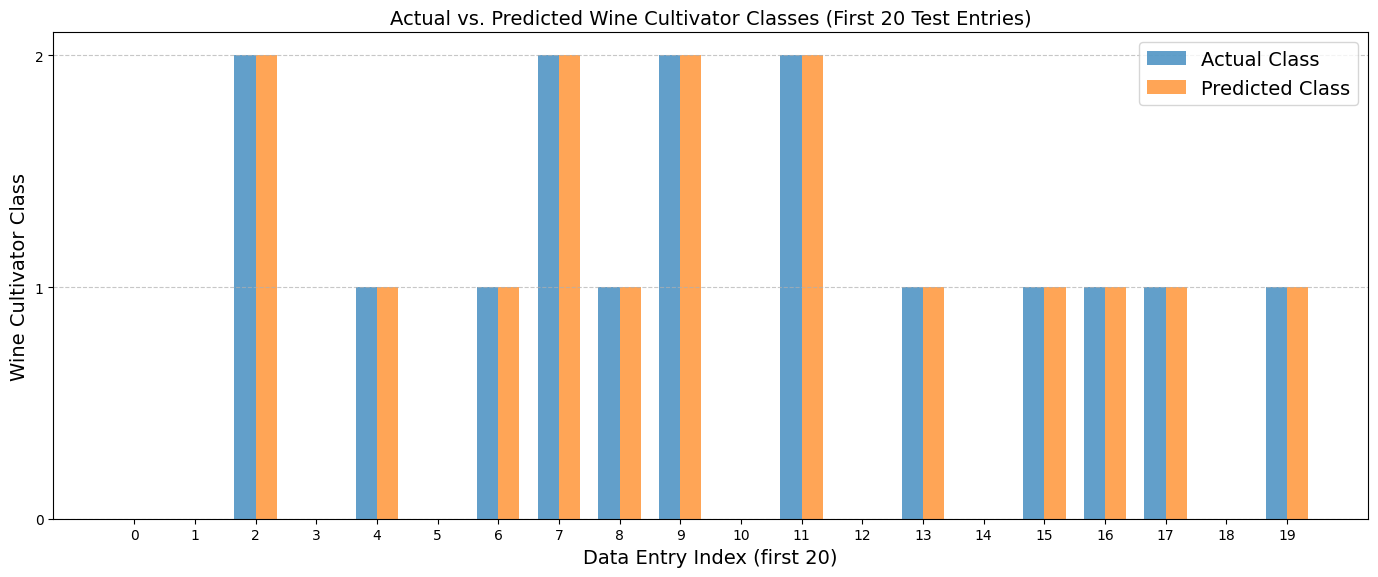

In [25]:
import matplotlib.pyplot as plt
import pandas as pd

# Get predictions for the test set
y_pred_test = rnd_search_cv.best_estimator_.predict(X_test)

# Take the first 20 entries
num_entries = 20
actual_classes = y_test[:num_entries]
predicted_classes = y_pred_test[:num_entries]

# Create a DataFrame for easier plotting
plot_df = pd.DataFrame({
    'Actual': actual_classes,
    'Predicted': predicted_classes
})

# Create a bar plot to visualize the comparison
fig = plt.figure(figsize=(14, 6))
x = range(num_entries)
width = 0.35

plt.bar([i - width/2 for i in x], plot_df['Actual'], width, label='Actual Class', alpha=0.7)
plt.bar([i + width/2 for i in x], plot_df['Predicted'], width, label='Predicted Class', alpha=0.7)

plt.xlabel('Data Entry Index (first 20)')
plt.ylabel('Wine Cultivator Class')
plt.title('Actual vs. Predicted Wine Cultivator Classes (First 20 Test Entries)')
plt.xticks(x)
plt.yticks([0, 1, 2])
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Reflection**

Give two real-world business or technology applications that you can use SVM on? What is the difference between LinearSVC vs kernelized SVM Why would you want to visualize the predicted vs actual results at the end the program? Write a statement on how you used AI in this assignment.

### Reflection Answers

1.  **Two real-world business or technology applications for SVM:**
    *   **Image Recognition and Classification:** SVMs are widely used in classifying images, such as recognizing handwritten digits, detecting objects in images, or classifying medical images (e.g., distinguishing between benign and malignant tumors). Their ability to handle high-dimensional data makes them suitable for image feature vectors.
    *   **Text Classification/Sentiment Analysis:** SVMs can be applied to categorize text documents (e.g., spam detection, news categorization) or analyze the sentiment of reviews (positive, negative, neutral). They are effective in high-dimensional text feature spaces.

2.  **Difference between LinearSVC vs. Kernelized SVM:**
    *   **`LinearSVC`:** This is a type of Support Vector Machine specifically designed for linearly separable data. It finds a straight line (or hyperplane in higher dimensions) that best separates the classes. `LinearSVC` is generally faster and more scalable for large datasets, especially when the data is indeed linearly separable or approximately so. It's an implementation of `Linear Support Vector Classification` that uses the `liblinear` library.
    *   **Kernelized SVM (e.g., `SVC` with a kernel):** This type of SVM can handle non-linearly separable data by using the "kernel trick." The kernel trick implicitly maps the input data into a higher-dimensional feature space where it *becomes* linearly separable. This allows the SVM to find non-linear decision boundaries in the original feature space. Common kernels include RBF (Radial Basis Function), polynomial, and sigmoid. Kernelized SVMs are more powerful for complex, non-linear relationships but can be slower to train than `LinearSVC` on very large datasets.

3.  **Why visualize predicted vs. actual results?**
    Visualizing predicted vs. actual results is crucial for several reasons:
    *   **Immediate Insight into Model Performance:** It provides a quick and intuitive understanding of how well the model is performing, especially in classification tasks. You can visually spot misclassifications.
    *   **Error Analysis:** By comparing specific predicted values to actual values, you can identify patterns in where the model makes mistakes. For instance, if certain classes are consistently misclassified, it might indicate issues with feature representation or class imbalance.
    *   **Trust and Interpretability:** A clear visualization helps build trust in the model by demonstrating its accuracy. For stakeholders, it's often easier to grasp a visual representation of performance than abstract metrics.
    *   **Debugging:** It can help in debugging if the model is behaving unexpectedly (e.g., consistently predicting one class over others, or producing strange patterns).

4.  **How AI was used in this assignment:**
    In this assignment, AI (specifically a large language model like myself) was used as an intelligent assistant to guide through the process of building and understanding Support Vector Machine models. I helped in explaining complex machine learning concepts (e.g., SVM convergence, feature scaling, kernelized SVMs, hyperparameter tuning), debugged code by identifying and suggesting fixes for `NameError` issues, and generated code for tasks such as data loading, model training, evaluation, and visualization. This allowed for a more interactive and efficient learning experience.